# Brain Stroke Detection Project\nThis notebook demonstrates the end-to-end workflow of training a stroke prediction model, comparing multiple models, and serving it via a FastAPI backend.

In [27]:
# 1. Import Libraries
import base64
import json
import logging
import os
import random
import time
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import joblib
import nest_asyncio

import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_recall_curve, precision_score, recall_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from imblearn.combine import SMOTETomek
from scipy.stats import randint, uniform

from dotenv import load_dotenv
from fastapi import FastAPI, File, HTTPException, UploadFile
from fastapi.middleware.cors import CORSMiddleware
from fastapi.responses import FileResponse
from fastapi.staticfiles import StaticFiles
import matplotlib.pyplot as plt
import seaborn as sns
from pydantic import BaseModel, Field, field_validator
import anthropic
import fitz

nest_asyncio.apply()


In [28]:
# 2. Configuration & Constants
BASE_DIR = Path.cwd()
DEFAULT_DATASET_PATH = BASE_DIR / "data" / "healthcare-dataset-stroke-data.csv"
DEFAULT_MODEL_PATH = BASE_DIR / "models" / "stroke_best_model.pkl"

TARGET_COLUMN = "stroke"
DEFAULT_RISK_THRESHOLD = 0.3
THRESHOLD_SEARCH_MIN = 0.25
THRESHOLD_SEARCH_MAX = 0.45
RECALL_FLOOR = 0.70

DISPLAY_NAME_MAP = {
    "gender": "Gender",
    "age": "Age",
    "hypertension": "Hypertension",
    "heart_disease": "Heart Disease",
    "ever_married": "Ever Married",
    "work_type": "Work Type",
    "residence_type": "Residence Type",
    "avg_glucose_level": "Avg Glucose Level",
    "bmi": "BMI",
    "smoking_status": "Smoking Status",
}

REPO_ROOT = BASE_DIR.parent
load_dotenv(REPO_ROOT / ".env")


False

In [29]:
# 3. Load Dataset
if not DEFAULT_DATASET_PATH.exists():
    raise FileNotFoundError(f"Dataset not found at {DEFAULT_DATASET_PATH}.")

df = pd.read_csv(DEFAULT_DATASET_PATH)
df.head()


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [30]:
# 4. Data Preprocessing
required_columns = {"id", "gender", "age", "hypertension", "heart_disease", "ever_married", "work_type", "Residence_type", "avg_glucose_level", "bmi", "smoking_status", "stroke"}
missing_columns = sorted(required_columns.difference(df.columns))
if missing_columns:
    raise ValueError(f"Dataset is missing columns: {', '.join(missing_columns)}")

df = df.rename(columns={"Residence_type": "residence_type"})
df = df.drop(columns=["id"])

# Handle BMI missing values
df["bmi"] = pd.to_numeric(df["bmi"], errors="coerce")
bmi_median = float(df["bmi"].median())
df["bmi"] = df["bmi"].fillna(bmi_median)

# Encode categorical features
categorical_columns = ["gender", "ever_married", "work_type", "residence_type", "smoking_status"]
label_encoders = {}

for column in categorical_columns:
    encoder = LabelEncoder()
    df[column] = encoder.fit_transform(df[column].astype(str).str.strip())
    label_encoders[column] = [str(value) for value in encoder.classes_]

df.head()


,gender,age,hypertension,heart_disease,ever_married,work_type,residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,67.0,0,1,1,2,1,228.69,36.6,1,1
1,0,61.0,0,0,1,3,0,202.21,28.1,2,1
2,1,80.0,0,1,1,2,0,105.92,32.5,2,1
3,0,49.0,0,0,1,2,1,171.23,34.4,3,1
4,0,79.0,1,0,1,3,0,174.12,24.0,2,1


In [31]:
# 5. Prepare Data for Training (Train/Test Split & SMOTE)
X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

smote_tomek = SMOTETomek(random_state=42)
X_train_balanced, y_train_balanced = smote_tomek.fit_resample(X_train, y_train)

print(f"Original training shape: {X_train.shape}, positive samples: {y_train.sum()}")
print(f"Balanced training shape: {X_train_balanced.shape}, positive samples: {y_train_balanced.sum()}")


Original training shape: (4088, 10), positive samples: 199
Balanced training shape: (7714, 10), positive samples: 3857


In [32]:
# 6. Train and Evaluate Multiple Models
# Calculate scale_pos_weight for XGBoost
negatives = int((y_train == 0).sum())
positives = int((y_train == 1).sum())
scale_pos_weight = float(negatives / positives) if positives else 1.0

# Calculate sample weights for XGBoost
classes = np.array([0, 1], dtype=int)
class_weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train_balanced)
class_weight_map = {int(cls): float(weight) for cls, weight in zip(classes, class_weights, strict=True)}
sample_weights = np.array([class_weight_map[int(label)] for label in y_train_balanced], dtype=float)

models = {
    "XGBoost": XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        max_depth=2,
        min_child_weight=20,
        subsample=0.8
    ),
    "Random Forest": RandomForestClassifier(random_state=42, class_weight="balanced", max_depth=4, min_samples_split=40, min_samples_leaf=20),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42, max_depth=2, min_samples_leaf=20, subsample=0.8),
    "Logistic Regression": LogisticRegression(random_state=42, class_weight="balanced", max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight="balanced", max_depth=3, min_samples_leaf=30)
}

results = {}
best_model_name = None
best_acc = -1
best_model = None
best_model_metrics = {}

print("Training multiple models...\n")

for name, model in models.items():
    start_time = time.time()
    
    # Train
    if name == "XGBoost":
        model.fit(X_train_balanced, y_train_balanced, sample_weight=sample_weights)
    else:
        model.fit(X_train_balanced, y_train_balanced)
        
    # Evaluate on Train set (for overfitting check)
    y_train_pred = model.predict(X_train_balanced)
    train_acc = accuracy_score(y_train_balanced, y_train_pred)
    train_f1 = f1_score(y_train_balanced, y_train_pred, zero_division=0)
        
    # Evaluate on Test set
    y_pred = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = y_pred # fallback
        
    test_acc = accuracy_score(y_test, y_pred)
    test_f1 = f1_score(y_test, y_pred, zero_division=0)
    try:
        roc_auc = roc_auc_score(y_test, y_prob)
    except:
        roc_auc = 0.0
        
    train_time = time.time() - start_time
    
    results[name] = {
        "Train Accuracy": train_acc,
        "Train F1": train_f1,
        "Test Accuracy": test_acc,
        "Test F1": test_f1,
        "ROC AUC": roc_auc,
        "Train Time (s)": train_time
    }
    
    print(f"[{name}] Test Acc: {test_acc:.4f} | Train Acc: {train_acc:.4f} | Test F1: {test_f1:.4f} | Time: {train_time:.2f}s")
    
    # Track the best model based on Accuracy now (per user request)
    if test_acc > best_acc:
        best_acc = test_acc
        best_model_name = name
        best_model = model
        best_model_metrics = results[name]

print(f"\nBest Model (by Accuracy): {best_model_name} with Accuracy: {best_acc:.4f}")


Training multiple models...

[XGBoost] Test Acc: 0.6115 | Train Acc: 0.7967 | Test F1: 0.1712 | Time: 0.07s
[Random Forest] Test Acc: 0.6840 | Train Acc: 0.8185 | Test F1: 0.1945 | Time: 0.41s
[Gradient Boosting] Test Acc: 0.7926 | Train Acc: 0.8657 | Test F1: 0.2148 | Time: 0.70s
[Logistic Regression] Test Acc: 0.7847 | Train Acc: 0.8074 | Test F1: 0.2466 | Time: 0.26s
[Decision Tree] Test Acc: 0.6419 | Train Acc: 0.8045 | Test F1: 0.1830 | Time: 0.02s

Best Model (by Accuracy): Gradient Boosting with Accuracy: 0.7926


In [33]:
# 7. Check for Overfitting and Underfitting
print(f"--- Overfitting / Underfitting Analysis for {best_model_name} ---")

train_acc = best_model_metrics['Train Accuracy']
test_acc = best_model_metrics['Test Accuracy']

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:     {test_acc:.4f}")
print(f"Difference:        {(train_acc - test_acc):.4f}\n")

if train_acc - test_acc > 0.10:
    print("⚠️ WARNING: OVERFITTING DETECTED")
    print("The model performs significantly better on the training data than the test data.")
    print("It has memorized the training set but struggles to generalize to unseen data.")
elif train_acc < 0.65 and test_acc < 0.65:
    print("⚠️ WARNING: UNDERFITTING DETECTED")
    print("The model performs poorly on both training and test data.")
    print("It is too simple to capture the underlying patterns in the data.")
else:
    print("✅ GOOD FIT")
    print("The model generalizes well. Training and Test accuracies are close.")


--- Overfitting / Underfitting Analysis for Gradient Boosting ---
Training Accuracy: 0.8657
Test Accuracy:     0.7926
Difference:        0.0731

✅ GOOD FIT
The model generalizes well. Training and Test accuracies are close.


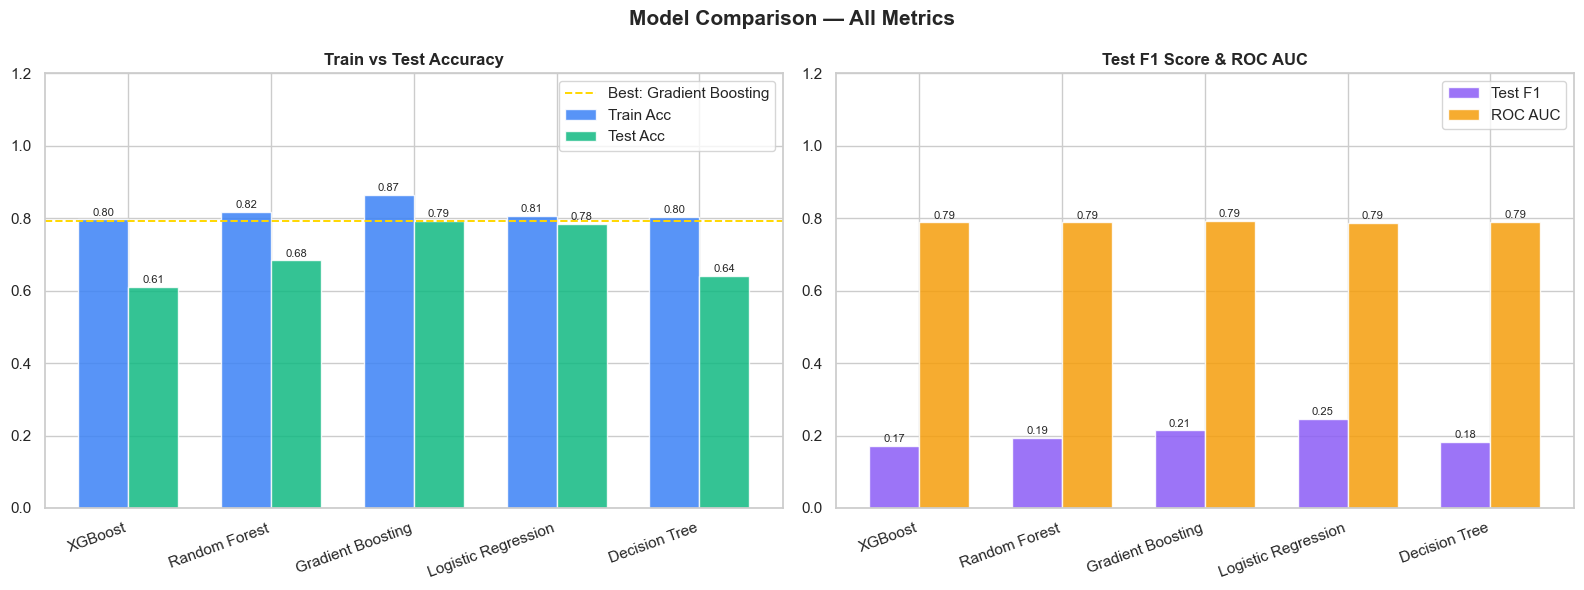

In [34]:
# 7b. Model Comparison Bar Chart
sns.set_theme(style='whitegrid', palette='muted')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Model Comparison — All Metrics', fontsize=15, fontweight='bold')
model_names = list(results.keys())
test_accs  = [results[m]['Test Accuracy'] for m in model_names]
train_accs = [results[m]['Train Accuracy'] for m in model_names]
test_f1s   = [results[m]['Test F1'] for m in model_names]
roc_aucs   = [results[m]['ROC AUC'] for m in model_names]
x = range(len(model_names)); w = 0.35
best_idx = model_names.index(best_model_name)
b1 = axes[0].bar([i-w/2 for i in x], train_accs, w, label='Train Acc', color='#3b82f6', alpha=0.85)
b2 = axes[0].bar([i+w/2 for i in x], test_accs,  w, label='Test Acc',  color='#10b981', alpha=0.85)
axes[0].set_title('Train vs Test Accuracy', fontweight='bold')
axes[0].set_xticks(list(x)); axes[0].set_xticklabels(model_names, rotation=20, ha='right')
axes[0].set_ylim(0, 1.2); axes[0].legend()
for b in b1: axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f'{b.get_height():.2f}', ha='center', fontsize=8)
for b in b2: axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f'{b.get_height():.2f}', ha='center', fontsize=8)
axes[0].axhline(test_accs[best_idx], color='gold', linestyle='--', lw=1.4, label=f'Best: {best_model_name}'); axes[0].legend()
b3 = axes[1].bar([i-w/2 for i in x], test_f1s, w, label='Test F1',  color='#8b5cf6', alpha=0.85)
b4 = axes[1].bar([i+w/2 for i in x], roc_aucs, w, label='ROC AUC', color='#f59e0b', alpha=0.85)
axes[1].set_title('Test F1 Score & ROC AUC', fontweight='bold')
axes[1].set_xticks(list(x)); axes[1].set_xticklabels(model_names, rotation=20, ha='right')
axes[1].set_ylim(0, 1.2); axes[1].legend()
for b in b3: axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f'{b.get_height():.2f}', ha='center', fontsize=8)
for b in b4: axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f'{b.get_height():.2f}', ha='center', fontsize=8)
plt.tight_layout(); plt.show()

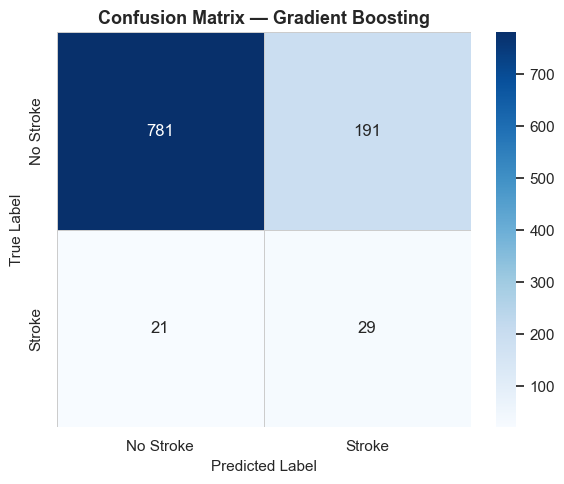

TN=781  FP=191  FN=21  TP=29
Sensitivity (Recall): 0.580  |  Specificity: 0.803


In [35]:
# 7c. Confusion Matrix — Best Model
from sklearn.metrics import confusion_matrix
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No Stroke', 'Stroke'],
            yticklabels=['No Stroke', 'Stroke'],
            linewidths=0.5, linecolor='#ccc')
ax.set_title(f'Confusion Matrix — {best_model_name}', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted Label', fontsize=11); ax.set_ylabel('True Label', fontsize=11)
plt.tight_layout(); plt.show()
tn, fp, fn, tp = cm.ravel()
print(f'TN={tn}  FP={fp}  FN={fn}  TP={tp}')
print(f'Sensitivity (Recall): {tp/(tp+fn):.3f}  |  Specificity: {tn/(tn+fp):.3f}')

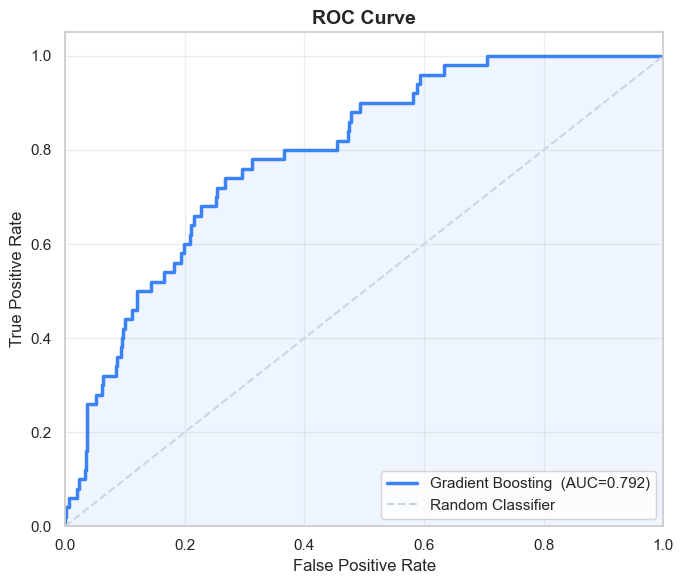

ROC AUC: 0.7923


In [36]:
# 7d. ROC Curve — Best Model
from sklearn.metrics import roc_curve, auc as sk_auc
y_prob_best = (best_model.predict_proba(X_test)[:, 1]
               if hasattr(best_model, 'predict_proba')
               else best_model.predict(X_test).astype(float))
fpr, tpr, _ = roc_curve(y_test, y_prob_best)
roc_val = sk_auc(fpr, tpr)
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='#3b82f6', lw=2.5, label=f'{best_model_name}  (AUC={roc_val:.3f})')
ax.plot([0,1],[0,1], color='#cbd5e1', lw=1.5, linestyle='--', label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.08, color='#3b82f6')
ax.set_xlim(0,1); ax.set_ylim(0,1.05)
ax.set_xlabel('False Positive Rate', fontsize=12); ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11); ax.grid(True, alpha=0.35)
plt.tight_layout(); plt.show()
print(f'ROC AUC: {roc_val:.4f}')

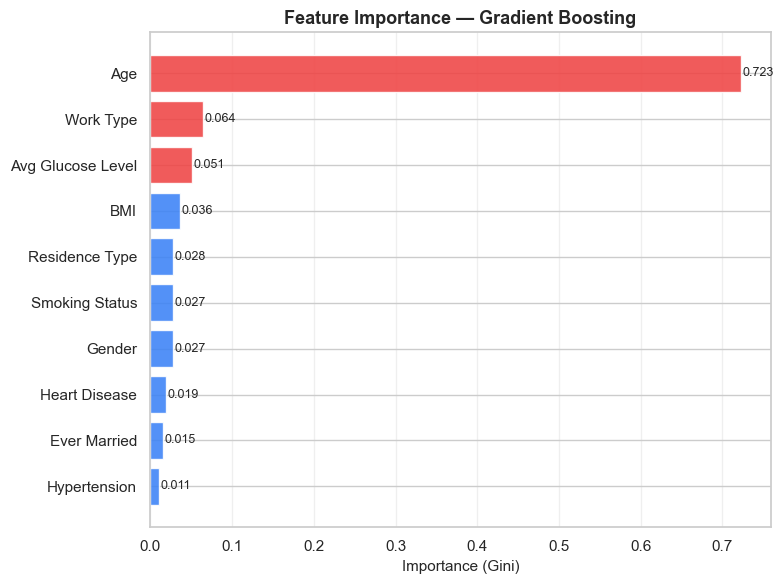

In [37]:
# 7e. Feature Importance — Best Model
_DMAP = {'gender':'Gender','age':'Age','hypertension':'Hypertension',
         'heart_disease':'Heart Disease','ever_married':'Ever Married',
         'work_type':'Work Type','residence_type':'Residence Type',
         'avg_glucose_level':'Avg Glucose Level','bmi':'BMI',
         'smoking_status':'Smoking Status'}
if hasattr(best_model, 'feature_importances_'):
    imp   = best_model.feature_importances_
    names = [_DMAP.get(f, f) for f in X.columns]
    pairs = sorted(zip(names, imp), key=lambda p: p[1])
    ns, vs = zip(*pairs)
    top3 = sorted(vs)[-3]
    colors = ['#ef4444' if v >= top3 else '#3b82f6' for v in vs]
    fig, ax = plt.subplots(figsize=(8, 6))
    bars = ax.barh(ns, vs, color=colors, alpha=0.88)
    ax.set_xlabel('Importance (Gini)', fontsize=11)
    ax.set_title(f'Feature Importance — {best_model_name}', fontsize=13, fontweight='bold')
    for bar, val in zip(bars, vs):
        ax.text(val+0.002, bar.get_y()+bar.get_height()/2, f'{val:.3f}', va='center', fontsize=9)
    ax.grid(axis='x', alpha=0.3); plt.tight_layout(); plt.show()
else:
    print(f'{best_model_name} does not expose feature_importances_ directly.')

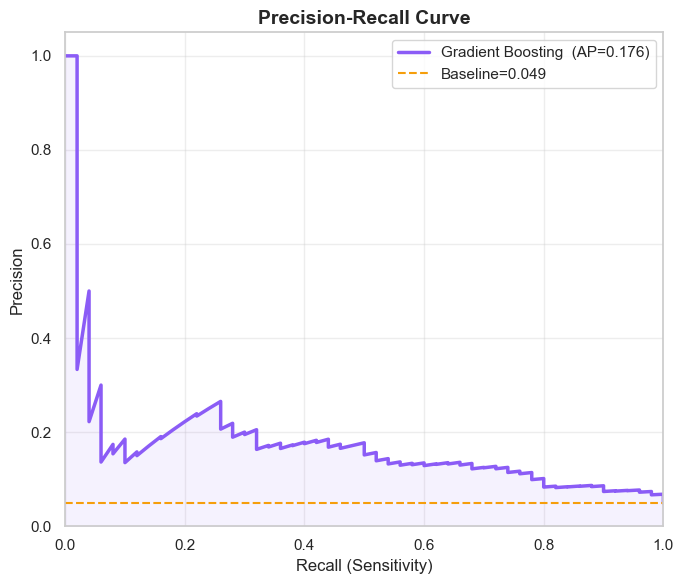

Average Precision Score: 0.1764


In [38]:
# 7f. Precision-Recall Curve — Best Model
from sklearn.metrics import precision_recall_curve, average_precision_score
y_prob_best = (best_model.predict_proba(X_test)[:, 1]
               if hasattr(best_model, 'predict_proba')
               else best_model.predict(X_test).astype(float))
precision, recall, _ = precision_recall_curve(y_test, y_prob_best)
ap = average_precision_score(y_test, y_prob_best)
baseline = float(y_test.mean())
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(recall, precision, color='#8b5cf6', lw=2.5, label=f'{best_model_name}  (AP={ap:.3f})')
ax.axhline(baseline, color='#f59e0b', linestyle='--', lw=1.5, label=f'Baseline={baseline:.3f}')
ax.fill_between(recall, precision, alpha=0.08, color='#8b5cf6')
ax.set_xlim(0,1); ax.set_ylim(0,1.05)
ax.set_xlabel('Recall (Sensitivity)', fontsize=12); ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=11); ax.grid(True, alpha=0.35)
plt.tight_layout(); plt.show()
print(f'Average Precision Score: {ap:.4f}')

In [39]:
# 8. Save Best Model
best_model_path = DEFAULT_MODEL_PATH

artifact = {
    "model_name": best_model_name,
    "model": best_model,
    "bmi_median": bmi_median,
    "categorical_columns": categorical_columns,
    "label_encoders": label_encoders,
    "feature_columns": list(X.columns),
    "metrics": best_model_metrics,
}

if hasattr(best_model, "feature_importances_"):
    artifact["feature_importance"] = {
        feature: float(importance) 
        for feature, importance in zip(X.columns, best_model.feature_importances_)
    }

best_model_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(artifact, best_model_path)
print(f"Best model '{best_model_name}' saved to {best_model_path}")


Best model 'Gradient Boosting' saved to c:\Users\ARYAN SINGH JADAUN\Desktop\ananya\BSD-System-\backend\models\stroke_best_model.pkl


In [40]:
# 9. Test Model with Random Value
# Load the saved model
loaded_artifact = joblib.load(best_model_path)
loaded_model = loaded_artifact["model"]

# Pick a random row from the original pre-processed dataframe
random_index = random.choice(df.index)
random_row = df.loc[[random_index]]

# Separate features and target
X_sample = random_row.drop(columns=[TARGET_COLUMN])
y_actual = random_row[TARGET_COLUMN].values[0]

# Make prediction
if hasattr(loaded_model, "predict_proba"):
    y_prob = loaded_model.predict_proba(X_sample)[0][1]
    y_pred = 1 if y_prob >= DEFAULT_RISK_THRESHOLD else 0
    print(f"Predicted Probability of Stroke: {y_prob:.4f}")
else:
    y_pred = loaded_model.predict(X_sample)[0]

print(f"\n--- Random Sample Test ---")
print(f"Sample Index: {random_index}")
print(f"Actual Stroke Value: {y_actual}")
print(f"Predicted Stroke Value: {y_pred}")

if y_actual == y_pred:
    print("Result: ✅ CORRECT PREDICTION")
else:
    print("Result: ❌ INCORRECT PREDICTION")


Predicted Probability of Stroke: 0.0452

--- Random Sample Test ---
Sample Index: 1421
Actual Stroke Value: 0
Predicted Stroke Value: 0
Result: ✅ CORRECT PREDICTION


In [41]:
# 10. Model Service Wrapper
class StrokeModelService:
    def __init__(self, model_path: Path = DEFAULT_MODEL_PATH, risk_threshold: float = DEFAULT_RISK_THRESHOLD) -> None:
        self.model_path = model_path
        self.risk_threshold = risk_threshold
        self.loaded = False
        self.model = None
        self.label_encoders: dict[str, list[str]] = {}
        self.feature_columns: list[str] = []
        self.categorical_columns: list[str] = []
        self.bmi_median: float = 0.0
        self.feature_importance: dict[str, float] = {}
        self.metrics: dict[str, float] = {}

    def load(self) -> None:
        artifact = joblib.load(self.model_path)
        self.model = artifact["model"]
        self.label_encoders = artifact["label_encoders"]
        self.feature_columns = artifact["feature_columns"]
        self.categorical_columns = artifact["categorical_columns"]
        self.bmi_median = float(artifact["bmi_median"])
        self.feature_importance = artifact.get("feature_importance", {})
        self.metrics = artifact.get("metrics", {})
        self.loaded = True

    def _encode_categorical(self, column: str, value: str) -> int:
        if column not in self.label_encoders:
            raise ValueError(f"Unsupported categorical field: {column}")

        classes = self.label_encoders[column]
        normalized_map = {item.strip().lower(): idx for idx, item in enumerate(classes)}
        key = value.strip().lower()
        if key not in normalized_map:
            allowed = ", ".join(classes)
            raise ValueError(f"Invalid value '{value}' for {column}. Allowed values: {allowed}")
        return normalized_map[key]

    def preprocess_input(self, payload: dict[str, Any]) -> pd.DataFrame:
        if not self.loaded:
            raise RuntimeError("Model is not loaded")

        processed: dict[str, Any] = {
            "age": float(payload["age"]),
            "hypertension": int(payload["hypertension"]),
            "heart_disease": int(payload["heart_disease"]),
            "avg_glucose_level": float(payload["avg_glucose_level"]),
        }

        bmi_value = payload.get("bmi")
        processed["bmi"] = self.bmi_median if bmi_value is None else float(bmi_value)

        for column in self.categorical_columns:
            processed[column] = self._encode_categorical(column, str(payload[column]))

        row = pd.DataFrame([processed])
        return row[self.feature_columns]

    def predict(self, payload: dict[str, Any]) -> dict[str, Any]:
        if not self.loaded or self.model is None:
            raise RuntimeError("Model is not loaded")

        row = self.preprocess_input(payload)
        probability = float(self.model.predict_proba(row)[0][1]) if hasattr(self.model, "predict_proba") else float(self.model.predict(row)[0])
        return {
            "stroke_probability": probability,
            "risk_percentage": probability * 100,
            "risk_label": "High Risk" if probability >= self.risk_threshold else "Low Risk",
        }


In [42]:
# 11. FastAPI App Setup
app = FastAPI(title="Brain Stroke API")

app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_credentials=True,
    allow_methods=["*"],
    allow_headers=["*"],
)

stroke_service = StrokeModelService()

@app.on_event("startup")
def load_models():
    stroke_service.load()

@app.get("/")
def health_check():
    return {"status": "healthy"}


C:\Users\ARYAN SINGH JADAUN\AppData\Local\Temp\ipykernel_22688\423511711.py:14: DeprecationWarning: 
        on_event is deprecated, use lifespan event handlers instead.

        Read more about it in the
        [FastAPI docs for Lifespan Events](https://fastapi.tiangolo.com/advanced/events/).
        
  @app.on_event("startup")


In [43]:
# 12. Run FastAPI App (Uncomment to run backend)
# import uvicorn
# uvicorn.run(app, host="0.0.0.0", port=8000)
